# Bag of Words Exploration Notebook

## 1. Setup 

In [2]:
import os
import glob
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Directory containing .txt files
DATA_DIR = "data"  # change this path

## 2. Load documents 

In [3]:
filepaths = glob.glob(os.path.join(DATA_DIR, "*.txt"))

corpus = []
filenames = []

for fp in filepaths:
    with open(fp, 'r', encoding='utf-8', errors='ignore') as f:
        corpus.append(f.read())
        filenames.append(os.path.basename(fp))

print(f"Loaded {len(corpus)} documents")

Loaded 762 documents


## 3. Create Bag-of-Words representation 

In [4]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_df=0.9,
    min_df=2
)

X = vectorizer.fit_transform(corpus)

print("Matrix shape:", X.shape)

Matrix shape: (762, 40542)


## 4. Convert to DataFrame for exploration 

In [5]:
feature_names = vectorizer.get_feature_names_out()

bow_df = pd.DataFrame(X.toarray(), columns=feature_names, index=filenames)

bow_df.head()

,00,000,01,02,03,03p,046,05,07,08,...,zoos,zora,zorro,zu,zub,zubowski,zubowskis,zucchini,zulu,über
412 Brisk Money.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
164 Specimen 313.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
270 When We Were Heroes.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
720 Tie A Yellow Ribbon.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
176 Apologue.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5. Most common words overall 

In [6]:
word_counts = bow_df.sum(axis=0).sort_values(ascending=False)

print("Top 20 words:")
print(word_counts.head(20))

Top 20 words:
didn      8818
don       8773
right     6637
man       6490
ll        6195
people    6015
little    5951
looked    5749
face      5361
ve        5357
got       5307
want      5295
going     5291
old       4779
says      4596
door      4514
came      4497
knew      4329
left      4291
took      4207
dtype: int64


## 6. Most important words per document 

In [7]:
def top_words_per_doc(df, n=10):
    results = {}
    for doc in df.index:
        top_words = df.loc[doc].sort_values(ascending=False).head(n)
        results[doc] = top_words[top_words > 0]
    return results

per_doc = top_words_per_doc(bow_df)

# Example: show one document
example_doc = list(per_doc.keys())[0]
print(f"\nTop words in {example_doc}:")
print(per_doc[example_doc])


Top words in 412 Brisk Money.txt:
ada       88
didn      68
man       45
gun       35
maybe     32
door      32
wasn      32
car       30
memory    28
inside    27
Name: 412 Brisk Money.txt, dtype: int64


## 7. Document similarity (cosine similarity) 

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X)

sim_df = pd.DataFrame(similarity_matrix, index=filenames, columns=filenames)

sim_df.head()

,412 Brisk Money.txt,164 Specimen 313.txt,270 When We Were Heroes.txt,720 Tie A Yellow Ribbon.txt,176 Apologue.txt,616 Dark Warm Heart.txt,186 Tortured.txt,107 River of Souls.txt,659 Grace's Family.txt,006 The Things That Make Me Weak and Strange Get Engineered Away.txt,...,131 Our Candidate.txt,378 Noma Girl.txt,568 The Night Cyclist.txt,221 At the Foot of the Lighthouse (Todai Moto Kurashi).txt,555 Once More Into the Abyss.txt,589 The Thing About Growing up in Jokertown.txt,"525 Tom, Thom.txt",108 Intersections and Interlopers.txt,825 The Sisters of Saint Nicola of The Almost Perpetual Motion vs the Lurch.txt,629 Waiting on a Bright Moon.txt
412 Brisk Money.txt,1.000000,0.255871,0.430892,0.381872,0.107304,0.352948,0.240768,0.265121,0.292221,0.443925,...,0.287113,0.384215,0.370354,0.272082,0.288581,0.312155,0.125698,0.190687,0.195533,0.245855
164 Specimen 313.txt,0.255871,1.000000,0.276981,0.239627,0.083085,0.231157,0.200833,0.169884,0.234719,0.253892,...,0.223272,0.226802,0.230343,0.211770,0.230244,0.226929,0.104766,0.150086,0.147202,0.179439
270 When We Were Heroes.txt,0.430892,0.276981,1.000000,0.405093,0.127069,0.333897,0.253419,0.265586,0.338180,0.434916,...,0.293381,0.376685,0.382511,0.421788,0.373051,0.509691,0.299431,0.218375,0.208805,0.387574
720 Tie A Yellow Ribbon.txt,0.381872,0.239627,0.405093,1.000000,0.128966,0.288699,0.234750,0.251246,0.295350,0.366490,...,0.379966,0.338882,0.292268,0.270204,0.304971,0.309596,0.141226,0.201351,0.202988,0.219271
176 Apologue.txt,0.107304,0.083085,0.127069,0.128966,1.000000,0.091063,0.102387,0.128445,0.101261,0.132941,...,0.107462,0.115305,0.122017,0.108699,0.096840,0.144051,0.056195,0.078831,0.077554,0.130003


## 8. Find most similar documents 

In [9]:
def most_similar(df, doc_name, top_n=5):
    sims = df.loc[doc_name].drop(doc_name)
    return sims.sort_values(ascending=False).head(top_n)

print(f"\nDocuments most similar to {example_doc}:")
print(most_similar(sim_df, example_doc))


Documents most similar to 412 Brisk Money.txt:
300 The Button Man and the Murder Tree.txt        0.529530
180 Trading Hearts at the Half Kaffe Café.txt    0.497232
148 The Rook.txt                                  0.494319
138 Shtetl Days.txt                               0.493887
317 One.txt                                       0.483170
Name: 412 Brisk Money.txt, dtype: float64


## 9. Optional: visualize top words 

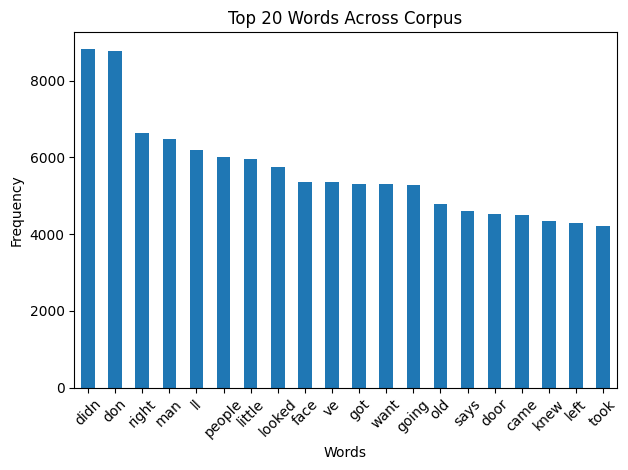

In [11]:
import matplotlib.pyplot as plt

word_counts.head(20).plot(kind='bar')
plt.title("Top 20 Words Across Corpus")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Save outputs 

In [12]:
bow_df.to_csv("outputs/bow_matrix.csv")
sim_df.to_csv("outputs/document_similarity.csv")

print("Saved outputs: bow_matrix.csv, document_similarity.csv")

Saved outputs: bow_matrix.csv, document_similarity.csv
